# Convolutional Neural Network (CNN) for flower classification with deep learning (TensorFlow)

In [ ]:
"""
# Project title:
End-to-end flower classification with CNN and Deep Learning Technique

# Project objective:
•	Apply data preprocessing such as normalized pixel values
•	Utilize pipeline optimization
•	Use multi-class image classification for creating a CNN model
•	Use both augmentation and regularization techniques to increase model accuracy
•	Test model accuracy and reliability with validation data.

# Key tech:
•	Google Colab, Python
•	TensorFlow / Keras (deep learning framework)
•	Data downloaded from tf.data with image directory
•	CNN model

"""

In [ ]:
import os

In [ ]:
# See clean results
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
import tensorflow as tf
from tensorflow import keras
import pathlib

# Download, extract, and load the flower image dataset

In [ ]:
# Load the dataset
dataset_path_url  = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
flower_dataset_dir = tf.keras.utils.get_file('flower_photos', origin = dataset_path_url, untar=True)
flower_dataset_dir = pathlib.Path(flower_dataset_dir) / 'flower_photos'

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Examine and confirm images in the flower dataset
flower_dataset_dir

PosixPath('/root/.keras/datasets/flower_photos/flower_photos')

In [ ]:
# Review sunflowers images

!ls /root/.keras/datasets/flower_photos/flower_photos/sunflowers/

1008566138_6927679c8a.jpg     3950020811_dab89bebc0_n.jpg
1022552002_2b93faf9e7_n.jpg   3951246342_930138610b_n.jpg
1022552036_67d33d5bd8_n.jpg   4019748730_ee09b39a43.jpg
10386503264_e05387e1f7_m.jpg  40410686_272bc66faf_m.jpg
10386522775_4f8c616999_m.jpg  40410814_fba3837226_n.jpg
10386525005_fd0b7d6c55_n.jpg  40410963_3ac280f23a_n.jpg
10386525695_2c38fea555_n.jpg  40411019_526f3fc8d9_m.jpg
10386540106_1431e73086_m.jpg  40411100_7fbe10ec0f_n.jpg
10386540696_0a95ee53a8_n.jpg  4042816698_578a1d599e.jpg
10386702973_e74a34c806_n.jpg  4080112931_cb20b3d51a_n.jpg
1043442695_4556c4c13d_n.jpg   4110787181_f73f12d107_m.jpg
1044296388_912143e1d4.jpg     4160805260_cf758daeae_n.jpg
1064662314_c5a7891b9f_m.jpg   417251603_69f0ee57a9_m.jpg
10862313945_e8ed9202d9_m.jpg  418056361_1dfac1c151_n.jpg
11881770944_22b4f2f8f6_n.jpg  4186808407_06688641e2_n.jpg
1217254584_4b3028b93d.jpg     4191299785_a4faca9b74_n.jpg
12282924083_fb80aa17d4_n.jpg  4235259239_21f2eb4f2e.jpg
1240624822_4111dde542.jpg     42

# Presenting a few sample images of sunflowers

In [ ]:
"""
Detect all flower categories

"""

flower_categories = [flower_type.name for flower_type in flower_dataset_dir.iterdir() if flower_type.is_dir()]
print('Flower categories:', flower_categories)



Flower categories: ['roses', 'sunflowers', 'dandelion', 'tulips', 'daisy']


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image


total_number_of_images  = len(list(flower_dataset_dir.glob('*/*.jpg')))
print(f'total number of images : {total_number_of_images}')

total number of images : 3670


In [ ]:
roses = list(flower_dataset_dir.glob('roses/*'))

sunflowers = list(flower_dataset_dir.glob('sunflowers/*'))

daisy = list(flower_dataset_dir.glob('daisy/*'))

tulips = list(flower_dataset_dir.glob('tulips/*'))


def view_image(image_file_location):
    img = Image.open(str(image_file_location))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

Roses


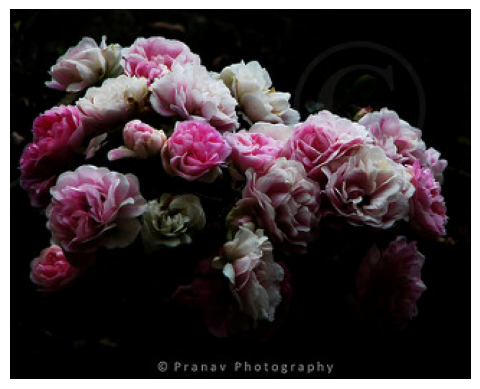

Sunflowers


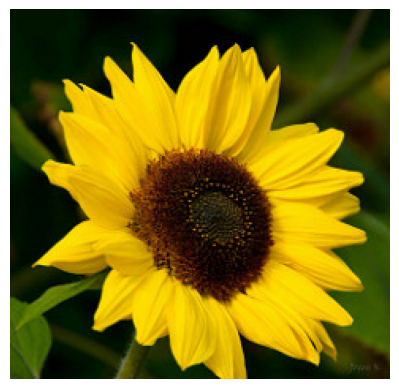

Daisy


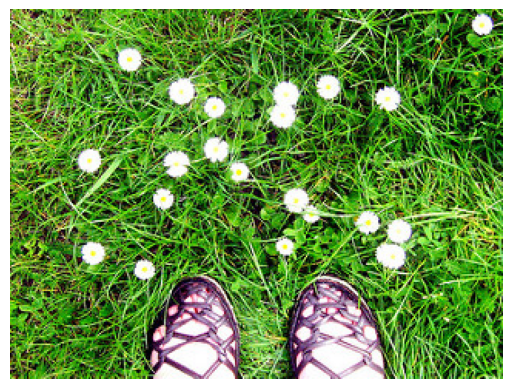

Tulips


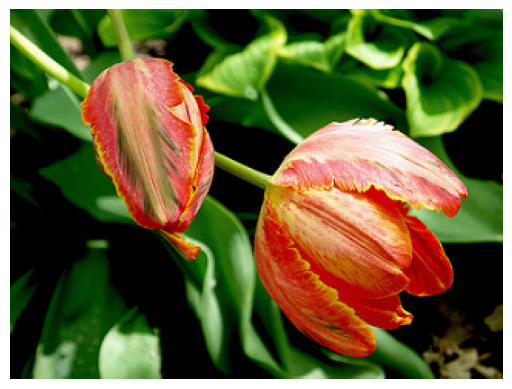

In [ ]:
# View images from each flower category ['dandelion', 'roses', 'sunflowers', 'daisy', 'tulips']

if len(roses) > 0:
  print("Roses")
  view_image(roses[0])

if len(sunflowers) > 0:
  print("Sunflowers")
  view_image(sunflowers[0])

if len(daisy) > 0:
  print("Daisy")
  view_image(daisy[0])

if len(tulips) > 0:
  print("Tulips")
  view_image(tulips[0])

In [ ]:
# Preparing Training Data with Resizing, Batching, and Validation Split

# Training dataset creation with validation split, resizing, and batching

In [ ]:
image_height = 175
image_width = 175
samples_per_batch = 32

# 80% of original data (flower_dataset_dir) for training the model
training_dataset = tf.keras.utils.image_dataset_from_directory(flower_dataset_dir,
                                                               validation_split = 0.2,
                                                               seed = 42,
                                                               batch_size = samples_per_batch,
                                                               subset = 'training',
                                                               image_size = (image_height, image_width)
                                                               )

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


# Previewing some training images with ground truth labels

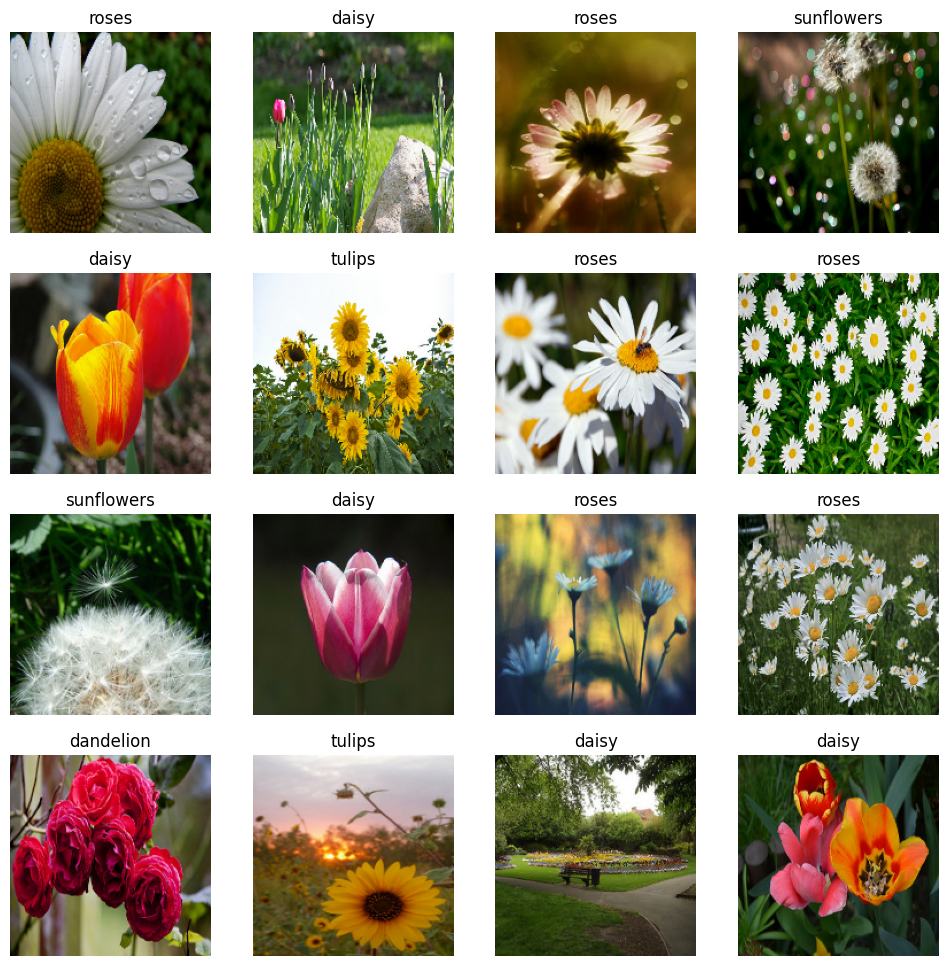

In [ ]:
plt.figure(figsize=(12, 12))
for input_images, class_labels in training_dataset.take(1):
  for i in range(16):
    subplot = plt.subplot(4, 4, i + 1)
    subplot.imshow(input_images[i].numpy().astype("uint8"))
    subplot.set_title(flower_categories[class_labels[i]])
    subplot.axis("off")
  plt.show()

# Creating validation dataset

In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(flower_dataset_dir,
                                                               validation_split = 0.2,
                                                               seed = 42,
                                                               batch_size = samples_per_batch,
                                                               subset = 'validation',
                                                               image_size = (image_height, image_width)
                                                               )

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


# Preprocessing for training and validation datasets with caching, shuffling, and normalization for results optimization

In [ ]:
# Automatically optimize parallel execution with tensorflow
tf_autotune = tf.data.AUTOTUNE

# Cache, shuffle, and prefetch the training dataset to enhance results with randomness.
train_data_optimized = training_dataset.cache().shuffle(1000).prefetch(buffer_size = tf_autotune)
validation_data_optimized  = validation_dataset.cache().prefetch(buffer_size =  tf_autotune)

In [ ]:
import numpy as np

from tensorflow.keras import layers

# Normalize pixel values from [0, 255] to [0, 1]
image_normalization_layer = layers.Rescaling(1./255)

# Normalize training images without changing image labels
normalized_training_dataset = train_data_optimized.map(lambda a, b: (image_normalization_layer(a), b))

# Normalize validation images without changing image labels
normalized_validation_dataset  = validation_data_optimized.map(lambda a, b: (image_normalization_layer(a), b))

# Load one batch of images and labels from the training images dataset
batch_images, batch_labels = next(iter(normalized_training_dataset))

In [ ]:
# See the second image involved in  the batch
second_image = batch_images[1]


print(np.min(second_image), np.max(second_image))

0.0 0.96905595


# Building a Convolutional Neural Network (CNN) for flower classification

In [ ]:
from tensorflow.keras.models import Sequential

# Improve training data with random transformations (flip, rotation, zoom)
image_transform_layer = keras.Sequential([layers.RandomFlip('horizontal', input_shape = (image_height, image_width, 3)),
                                      layers.RandomRotation(0.15),
                                      layers.RandomZoom(0.15),
                                      ])

number_of_classes = len(flower_categories)


"""
Conv2D(16, 3, ..): 16 is number of different filters. 3 represents 3 x 3 filter window
MaxPooling2D() used to decrease image size
"""

model = Sequential([image_transform_layer,
                    # Convolutional block 1
                    layers.Conv2D(16, 3, padding = 'same', activation='relu'),
                    layers.MaxPooling2D(),

                    layers.Conv2D(32, 3, padding = 'same', activation='relu'),
                    layers.MaxPooling2D(),

                    layers.Conv2D(64, 3, padding = 'same', activation='relu'),
                    layers.MaxPooling2D(),

                    layers.Conv2D(128, 3, padding = 'same', activation='relu'),
                    layers.MaxPooling2D(),

                    layers.Dropout(0.2),


                    layers.Flatten(),
                    layers.Dense(256, activation = 'relu'),
                    layers.Dropout(0.4),
                    layers.Dense(128, activation = 'relu'),

                    layers.Dense(number_of_classes, activation='softmax')
                    ])


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 175, 175, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 175, 175, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 87, 87, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 43, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,408,037 (13.00 MB)

 Trainable params: 3,408,037 (13.00 MB)

 Non-trainable params: 0 (0.00 B)

# Training CNN model with Adam optimizer and sparse categorical loss

In [ ]:
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics = ['accuracy']
              )

epochs = 30

history = model.fit(normalized_training_dataset,
                    validation_data = normalized_validation_dataset,
                    epochs = epochs
                    )

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.3702 - loss: 1.3999 - val_accuracy: 0.4809 - val_loss: 1.1554
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.5106 - loss: 1.1277 - val_accuracy: 0.5477 - val_loss: 1.1107
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.5848 - loss: 1.0147 - val_accuracy: 0.6076 - val_loss: 0.9983
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.6110 - loss: 0.9507 - val_accuracy: 0.5817 - val_loss: 1.1485
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.6509 - loss: 0.8869 - val_accuracy: 0.6403 - val_loss: 0.9410
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6645 - loss: 0.8515 - val_accuracy: 0.6853 - val_loss: 0.8010
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6580 - loss: 0.8549 - val_accuracy: 0.6921 - val_loss: 0.8355
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.6880 - loss: 0.7877 - val_accuracy: 0.6662 - v

In [ ]:
train_accuracy = history.history['accuracy']
print(f'Train accuracy: {train_accuracy[-1]:.2f}')
print()

validation_accuracy = history.history['val_accuracy']
print(f'Validation accuracy: {validation_accuracy[-1]:.2f}')
print()

training_loss = history.history['loss']
print(f'training loss: {training_loss[-1]:.2f}')
print()

validation_loss = history.history['val_loss']
print(f'Validation loss: {validation_loss[-1]:.2f}')

Train accuracy: 0.83

Validation accuracy: 0.76

training loss: 0.44

Validation loss: 0.70


# Training and validation accuracy across epochs

Text(0.5, 1.0, 'Training and validation accuracy')

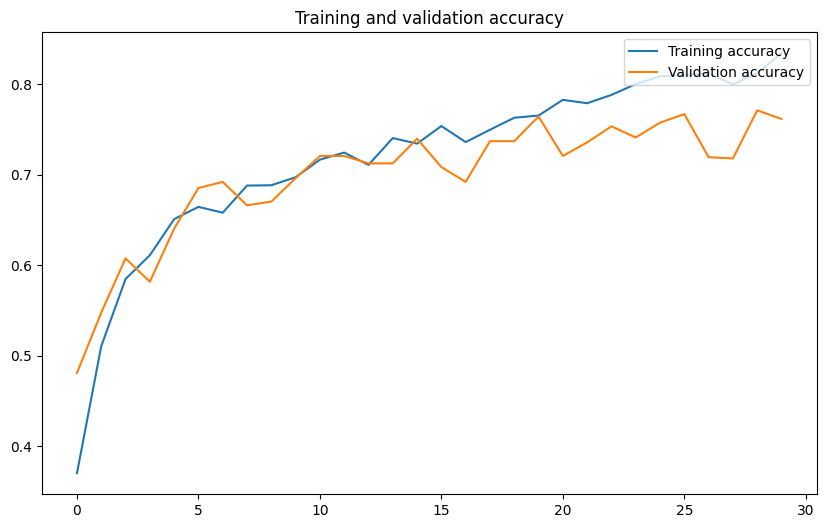

In [ ]:
epoch_steps = range(epochs)

plt.figure(figsize=(10, 6))
#plt.subplot(1, 2, 1)
plt.plot(epoch_steps, train_accuracy, label='Training accuracy')
plt.plot(epoch_steps, validation_accuracy, label = 'Validation accuracy')
plt.legend(loc='upper right')
plt.title('Training and validation accuracy')

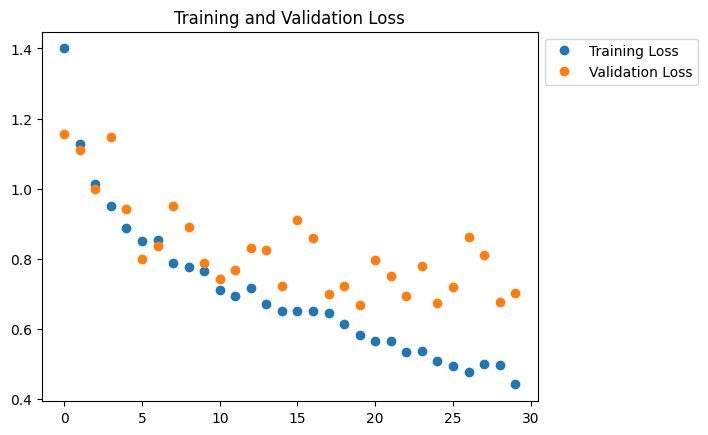

In [ ]:
plt.plot(epoch_steps, training_loss, marker = 'o', linestyle = 'None', label = 'Training Loss')
plt.plot(epoch_steps, validation_loss, marker = 'o', linestyle = 'None', label = 'Validation Loss')

plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))

plt.title('Training and Validation Loss')
plt.show()

#plt.legend(loc='upper right')
#plt.title('Training and Validation Loss')

# Flower classification on new image data

In [ ]:
sunflower_data_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_sample_red = tf.keras.utils.get_file('Red_sunflower', origin = sunflower_data_url)

loaded_image = tf.keras.utils.load_img(sunflower_sample_red, target_size = (image_height, image_width))

input_image_array = tf.keras.utils.img_to_array(loaded_image)

input_image_array = tf.expand_dims(input_image_array, 0)

prediction_scores = model.predict(input_image_array)

class_probabilities = tf.nn.softmax(prediction_scores[0])
print(class_probabilities)
print()

print('Predicted class: {} ({:.3f}% confidence)'.format(flower_categories[np.argmax(score)], 100 * np.max(class_probabilities)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
tf.Tensor([0.14884758 0.14884758 0.14884758 0.40460968 0.14884758], shape=(5,), dtype=float32)

Predicted class: tulips (40.461% confidence)
